In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA


### Get File path and load the csv data

In [7]:
from util.data_path import cassava_path

In [8]:
wide = pd.read_csv(cassava_path)
long = wide.melt(id_vars="year", var_name="month", value_name="price").sort_values(
    ["year", "month"]
)

long["date"] = pd.to_datetime(
    (long["year"] - 543).astype(str)
    + "-"
    + long["month"].astype(str).str.zfill(2)
    + "-01"
)
long = long.set_index("date").sort_index()

### Set the training dataset and the predicted data

In [9]:
gregorian_2566 = 2023
gregorian_2567 = 2024

train = long[long.index.year <= gregorian_2566]["price"].to_frame()
future = long[long.index.year == gregorian_2567]["price"].to_frame()

scaler = MinMaxScaler()
train["scaled"] = scaler.fit_transform(train[["price"]])

series = train["scaled"].values.astype(np.float32)

In [10]:
y_train = train["price"].asfreq("MS")
y_test = future["price"].asfreq("MS")

In [11]:
SEQ_LEN = 12
PRED_LEN = 12

In [16]:
sf_data = (
    y_train.rename("y")
    .to_frame()
    .assign(ds=lambda df: df.index, unique_id="cassava")
    .reset_index(drop=True)
)

sf = StatsForecast(
    models=[
        AutoARIMA(
            season_length=12,  # monthly
            approximation=False,
        )
    ],
    freq="MS",  # month start
)

sf_forecasts = sf.fit_predict(df=sf_data, h=12)
arima_sf = sf_forecasts.set_index("ds")["AutoARIMA"]

print("MAE =", mean_absolute_error(y_test, arima_sf))
display(pd.concat([y_test.rename("actual"), arima_sf], axis=1))

MAE = 0.576710246846437


,actual,AutoARIMA
2024-01-01,3.65,3.651541
2024-02-01,3.65,3.644331
2024-03-01,3.57,3.644331
2024-04-01,3.24,3.644331
2024-05-01,3.19,3.644331
2024-06-01,3.09,3.644331
2024-07-01,3.06,3.644331
2024-08-01,2.95,3.644331
2024-09-01,2.86,3.644331
2024-10-01,2.65,3.644331


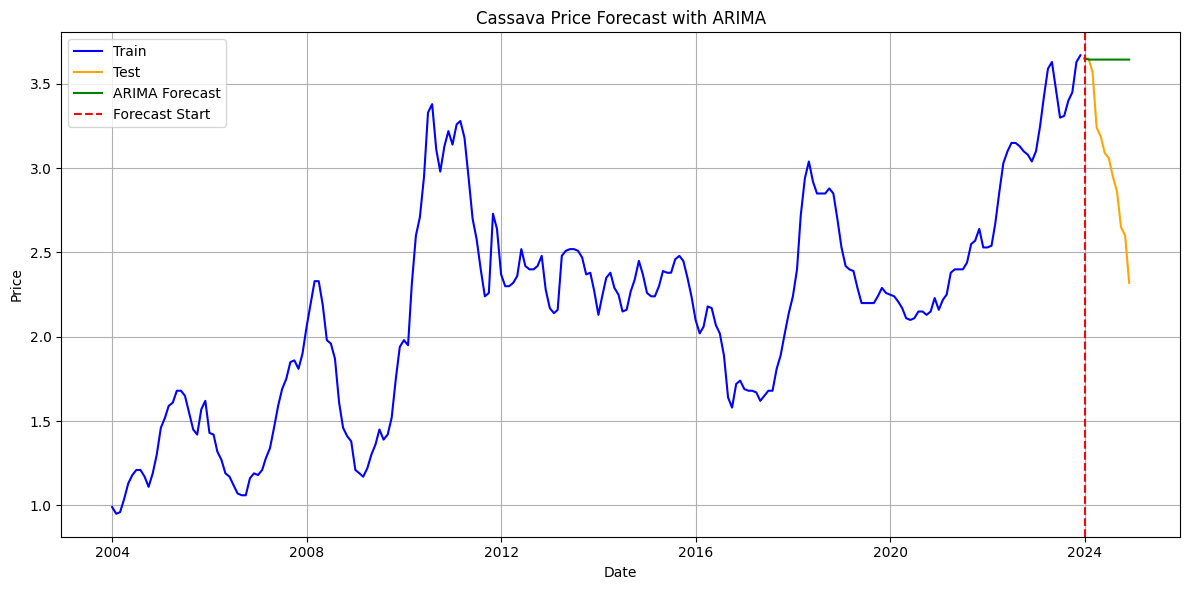

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y_train.index, y_train, label="Train", color="blue")
plt.plot(y_test.index, y_test, label="Test", color="orange")
plt.plot(arima_sf.index, arima_sf, label="ARIMA Forecast", color="green")
plt.axvline(
    x=pd.Timestamp(f"{gregorian_2567}-01-01"),
    color="red",
    linestyle="--",
    label="Forecast Start",
)
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Cassava Price Forecast with ARIMA")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()